In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [13]:
wscal = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_03_27_global_droughtmort/output_withfire/output/wscal.nc").wscal.sel(time = slice("2000","2019")).sel(lon = slice(-130,30), lat = slice(-50,120))
wscal

<xarray.DataArray 'wscal' (time: 240, lat: 1337, lon: 1600)> Size: 2GB
[513408000 values with dtype=float32]
Coordinates:
  * time     (time) object 2kB 2000-01-16 00:00:00 ... 2019-12-16 00:00:00
  * lat      (lat) float64 11kB -49.95 -49.85 -49.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 13kB -129.9 -129.8 -129.8 ... 29.75 29.85 29.95
Attributes:
    standard_name:  wscal
    long_name:      water scalar

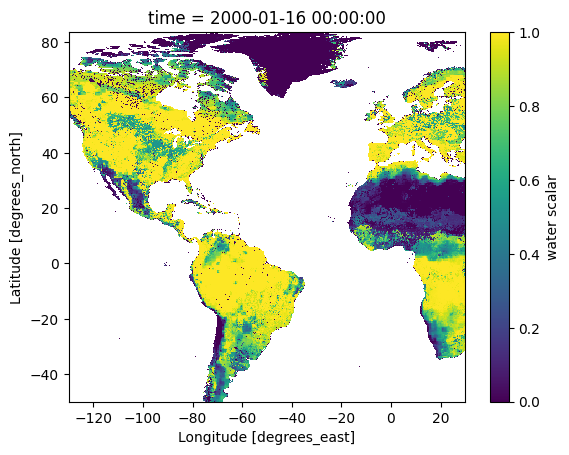

In [14]:
wscal[0].plot()

In [15]:
wscal_flat = wscal.values.flatten()

In [16]:
pft_mortdrought = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_03_27_global_droughtmort/output/pft_mort_drought.nc").sel(time = slice("2000","2019")).mortality[:,0:8].sel(lon = slice(-130,30), lat = slice(-50,120))
pft_mortdrought

<xarray.DataArray 'mortality' (time: 240, pft: 8, lat: 1337, lon: 1600)> Size: 16GB
[4107264000 values with dtype=float32]
Coordinates:
  * time     (time) object 2kB 2000-01-16 00:00:00 ... 2019-12-16 00:00:00
  * pft      (pft) int32 32B 1 2 3 4 5 6 7 8
  * lat      (lat) float64 11kB -49.95 -49.85 -49.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 13kB -129.9 -129.8 -129.8 ... 29.75 29.85 29.95
Attributes:
    units:          1/month
    standard_name:  mortality
    long_name:      Monthly drought mortality

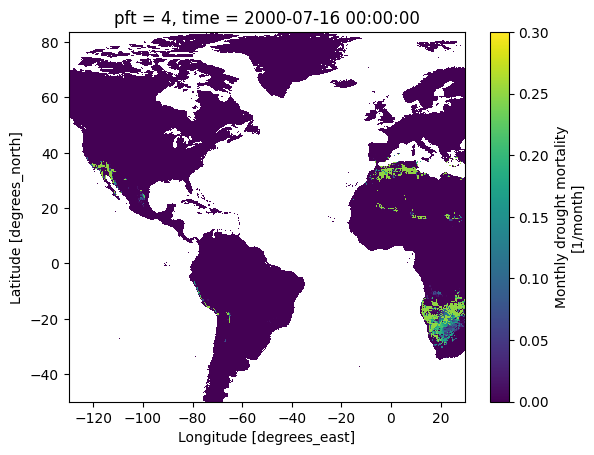

In [17]:
pft_mortdrought.sel(pft=4)[6].plot(vmax = 0.3)

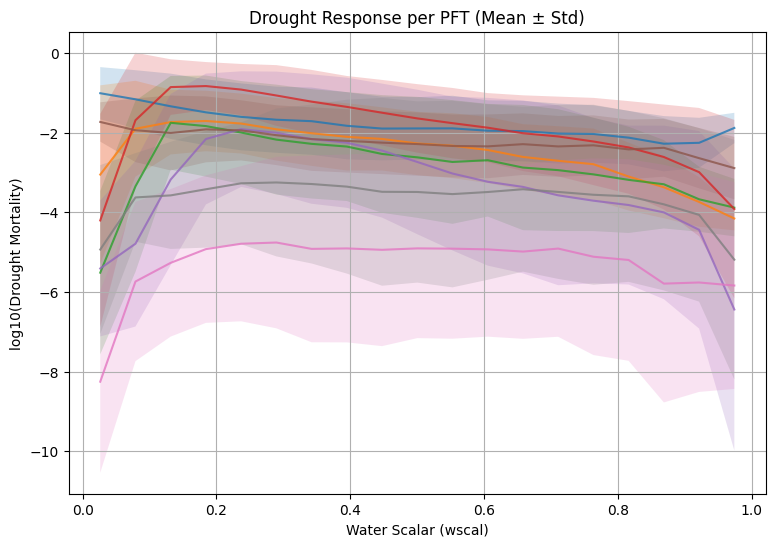

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# bins = np.linspace(0, 1, 20)
# bin_centers = 0.5 * (bins[:-1] + bins[1:])

# plt.figure(figsize=(9,6))

# for pft in pft_mortdrought.pft.values:
    
#     mort = pft_mortdrought.sel(pft=pft)
#     mort_flat = mort.values.flatten()
    
#     mask = np.isfinite(wscal_flat) & np.isfinite(mort_flat) & (mort_flat > 0)
    
#     x = wscal_flat[mask]
#     y = np.log10(mort_flat[mask])
    
#     means = []
#     stds = []
    
#     for i in range(len(bins)-1):
#         bin_mask = (x >= bins[i]) & (x < bins[i+1])
        
#         if np.any(bin_mask):
#             vals = y[bin_mask]
#             means.append(np.mean(vals))
#             stds.append(np.std(vals))
#         else:
#             means.append(np.nan)
#             stds.append(np.nan)
    
#     means = np.array(means)
#     stds = np.array(stds)
    
#     # Plot line
#     plt.plot(bin_centers, means, alpha=0.8)
    
#     # Plot uncertainty band
#     plt.fill_between(
#         bin_centers,
#         means - stds,
#         means + stds,
#         alpha=0.2
#     )

# plt.xlabel("Water Scalar (wscal)")
# plt.ylabel("log10(Drought Mortality)")
# plt.title("Drought Response per PFT (Mean ± Std)")
# plt.grid(True)

# plt.show()

In [18]:
pft_names = {
    1: "Tropical broadleaf evergreen",
    2: "Tropical broadleaf raingreen",
    
    3: "Temperate needleleaf evergreen",
    4: "Temperate broadleaf evergreen",
    5: "Temperate broadleaf summergreen",
    
    6: "Boreal needleleaf evergreen",
    7: "Boreal broadleaf summergreen",
    8: "Boreal needleleaf summergreen",
}

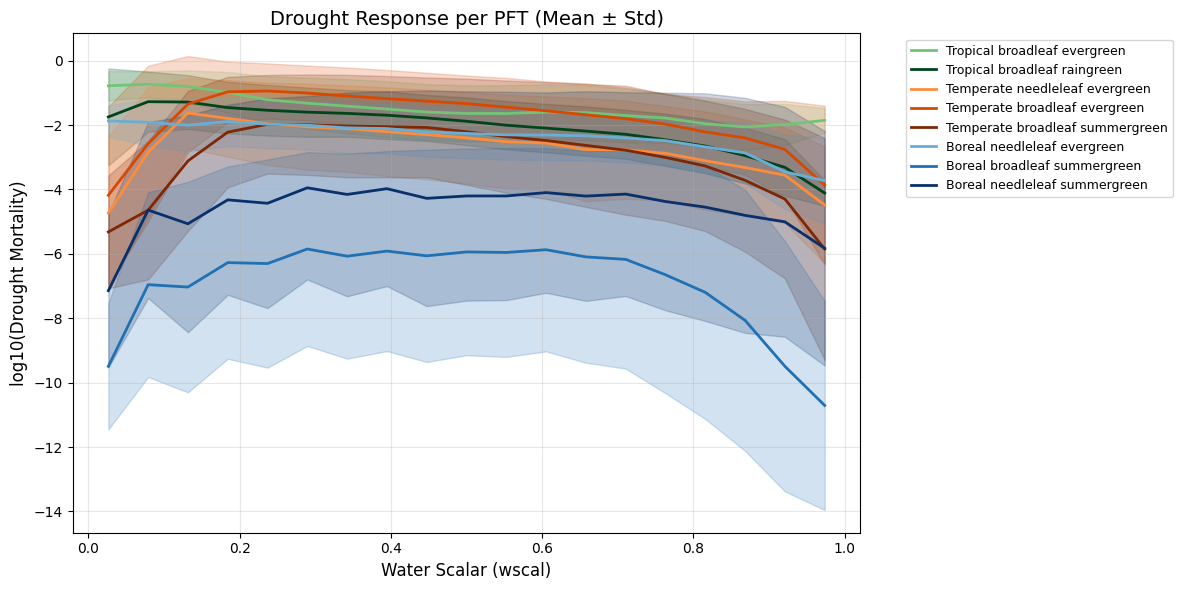

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

bins = np.linspace(0, 1, 20)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

plt.figure(figsize=(12,6))

# ---- PFT groups ----
tropical = [1, 2]
temperate = [3, 4, 5]
boreal = [6, 7, 8]

greens = cm.Greens(np.linspace(0.5, 1, len(tropical)))
oranges = cm.Oranges(np.linspace(0.5, 1, len(temperate)))
blues = cm.Blues(np.linspace(0.5, 1, len(boreal)))

pft_colors = {}
for i, pft in enumerate(tropical):
    pft_colors[pft] = greens[i]
for i, pft in enumerate(temperate):
    pft_colors[pft] = oranges[i]
for i, pft in enumerate(boreal):
    pft_colors[pft] = blues[i]

# ---- Plot ----
for pft in pft_mortdrought.pft.values:
    
    if pft not in pft_names:
        continue  # skip unused PFTs
    
    mort = pft_mortdrought.sel(pft=pft)
    mort_flat = mort.values.flatten()
    
    mask = np.isfinite(wscal_flat) & np.isfinite(mort_flat) & (mort_flat > 0)
    
    x = wscal_flat[mask]
    y = np.log10(mort_flat[mask])
    
    means = []
    stds = []
    
    for i in range(len(bins)-1):
        bin_mask = (x >= bins[i]) & (x < bins[i+1])
        
        if np.any(bin_mask):
            vals = y[bin_mask]
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    
    means = np.array(means)
    stds = np.array(stds)
    
    color = pft_colors[pft]
    
    plt.plot(bin_centers, means, color=color, linewidth=2,
             label=pft_names[pft])
    
    plt.fill_between(
        bin_centers,
        means - stds,
        means + stds,
        color=color,
        alpha=0.2
    )

# ---- Labels ----
plt.xlabel("Water Scalar (wscal)", fontsize=12)
plt.ylabel("log10(Drought Mortality)", fontsize=12)
plt.title("Drought Response per PFT (Mean ± Std)", fontsize=14)

plt.grid(alpha=0.3)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()